# NTB-10: Final Model Assembly & Production Serialization

## Objective
Package everything into `artifacts/`, write `src/predict.py`, run the final evaluation, and generate the README summary.

**Build order (important):**
1. Setup
2. Final evaluation
3. Summary plots
4. Assemble `artifacts/` ← must run BEFORE smoke test
5. Write `src/predict.py`
6. Smoke test
7. Model card JSON + README table

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os, json, joblib, shutil, datetime
import warnings; warnings.filterwarnings('ignore')

from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, brier_score_loss,
    log_loss, precision_recall_curve, roc_curve, confusion_matrix
)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

BASE_DIR      = Path(os.getcwd()).parent
PROC_DIR      = BASE_DIR / "data" / "processed"
MODELS_DIR    = BASE_DIR / "models"
FIG_DIR       = BASE_DIR / "reports" / "figures"
REPORTS_DIR   = BASE_DIR / "reports"
SRC_DIR       = BASE_DIR / "src"
ARTIFACTS_DIR = BASE_DIR / "artifacts"

ARTIFACTS_DIR.mkdir(exist_ok=True)
SRC_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "savefig.bbox": "tight"})
print(f"Artifacts: {ARTIFACTS_DIR}")
print(f"Src:       {SRC_DIR}")

Artifacts: c:\Users\Prakhar kapoor\Desktop\Telecom-Churn-Prediction-Analytics\artifacts
Src:       c:\Users\Prakhar kapoor\Desktop\Telecom-Churn-Prediction-Analytics\src


In [2]:
champion     = joblib.load(MODELS_DIR / "champion.joblib")
preprocessor = joblib.load(MODELS_DIR / "preprocessor.joblib")

with open(REPORTS_DIR / "ntb08_production_config.json") as f:
    prod_config = json.load(f)
with open(PROC_DIR / "feature_metadata.json") as f:
    feat_meta = json.load(f)

X_test  = pd.read_parquet(PROC_DIR / "X_test.parquet")
y_test  = pd.read_parquet(PROC_DIR / "y_test.parquet")['churn']
X_train = pd.read_parquet(PROC_DIR / "X_train.parquet")
y_train = pd.read_parquet(PROC_DIR / "y_train.parquet")['churn']

OPTIMAL_THRESHOLD = prod_config['optimal_threshold_business_value']
print(f"Champion: {prod_config['model_name']}")
print(f"Optimal threshold: {OPTIMAL_THRESHOLD}")

Champion: LightGBM (tuned)
Optimal threshold: 0.426


## 2. Final Evaluation

In [3]:
y_proba        = champion.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)
y_pred_optimal = (y_proba >= OPTIMAL_THRESHOLD).astype(int)

auc_roc = roc_auc_score(y_test, y_proba)
pr_auc  = average_precision_score(y_test, y_proba)
brier   = brier_score_loss(y_test, y_proba)
ll      = log_loss(y_test, y_proba)

cm_opt = confusion_matrix(y_test, y_pred_optimal)
tn, fp, fn, tp = cm_opt.ravel()
precision_opt = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall_opt    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1_opt = 2*precision_opt*recall_opt/(precision_opt+recall_opt) if (precision_opt+recall_opt) > 0 else 0.0

print("=" * 52)
print(f"  FINAL MODEL CARD  {prod_config['model_name']}")
print("=" * 52)
print(f"  AUC-ROC:   {auc_roc:.4f}  |  PR-AUC:  {pr_auc:.4f}")
print(f"  Brier:     {brier:.4f}  |  LogLoss: {ll:.4f}")
print(f"  At threshold {OPTIMAL_THRESHOLD}:")
print(f"  Precision: {precision_opt:.4f}  Recall: {recall_opt:.4f}  F1: {f1_opt:.4f}")
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"  Monthly value: ${prod_config['optimal_monthly_value_usd']:,.0f}")
print("=" * 52)

  FINAL MODEL CARD  LightGBM (tuned)
  AUC-ROC:   0.8492  |  PR-AUC:  0.6628
  Brier:     0.1588  |  LogLoss: 0.4745
  At threshold 0.426:
  Precision: 0.4984  Recall: 0.8476  F1: 0.6277
  TP=317  FP=319  FN=57  TN=716
  Monthly value: $329,527


## 3. Final Summary Plots

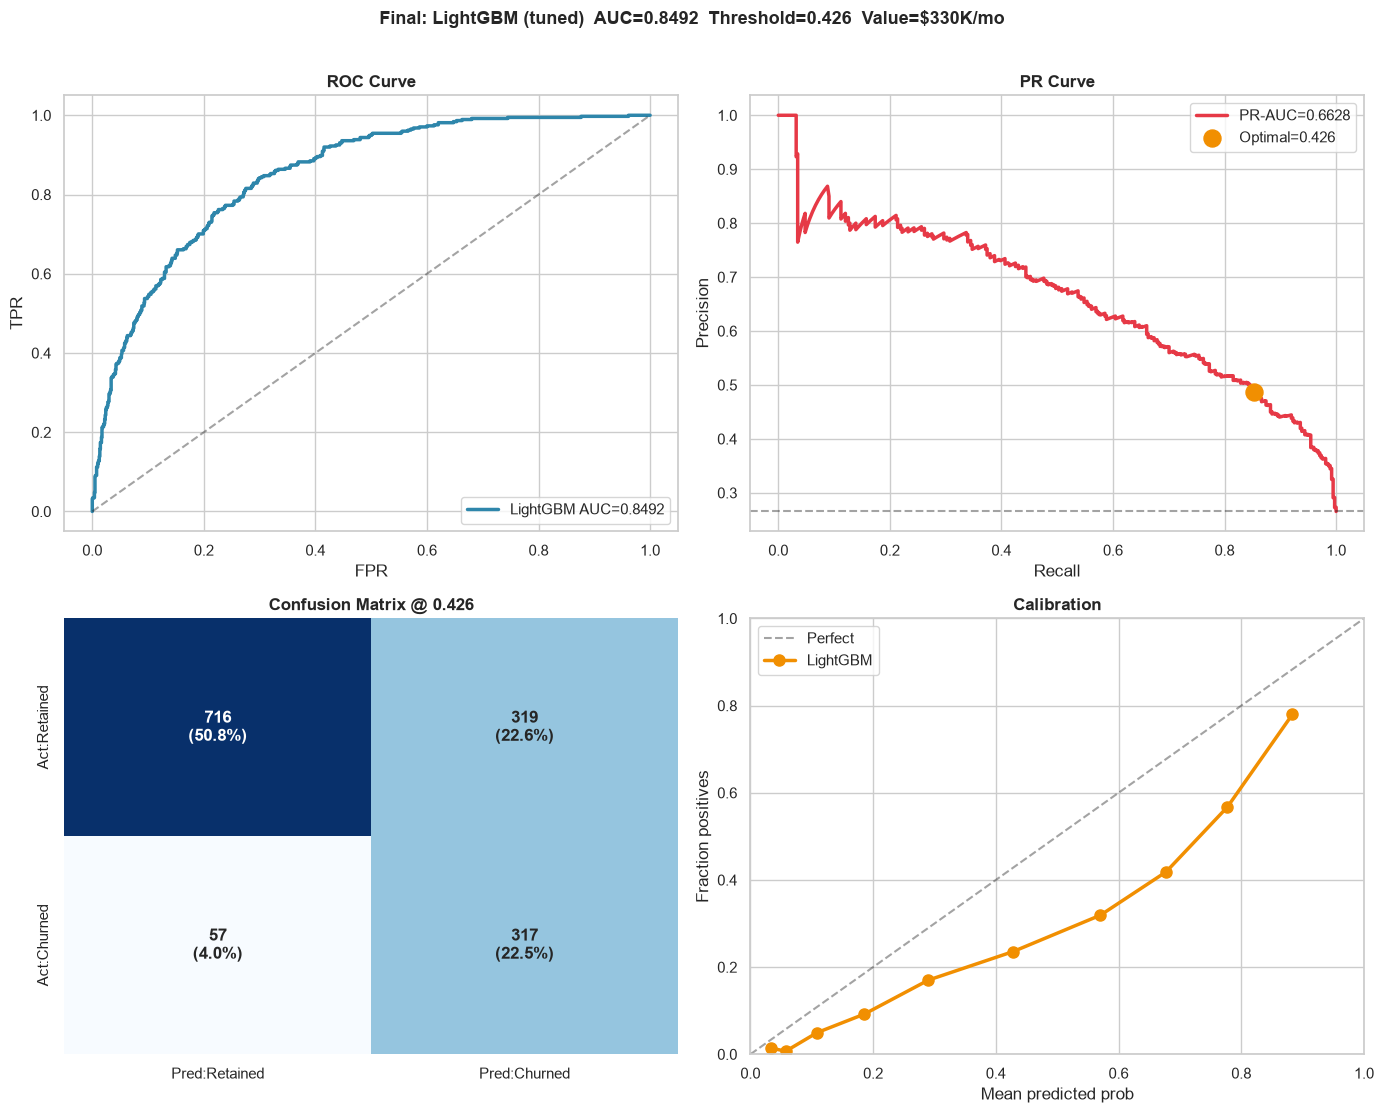

Saved -> NTB10_final_evaluation.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0,0].plot(fpr, tpr, '#2E86AB', lw=2.5, label=f'LightGBM AUC={auc_roc:.4f}')
axes[0,0].plot([0,1],[0,1],'k--',alpha=0.4)
axes[0,0].set_xlabel('FPR'); axes[0,0].set_ylabel('TPR')
axes[0,0].set_title('ROC Curve', fontweight='bold'); axes[0,0].legend(loc='lower right')

prec_arr, rec_arr, thr_pr = precision_recall_curve(y_test, y_proba)
axes[0,1].plot(rec_arr, prec_arr, '#E63946', lw=2.5, label=f'PR-AUC={pr_auc:.4f}')
axes[0,1].axhline(y_test.mean(), color='k', ls='--', alpha=0.4)
mask_thr = np.abs(thr_pr - OPTIMAL_THRESHOLD) < 0.02
if mask_thr.any():
    i = np.where(mask_thr)[0][0]
    axes[0,1].scatter([rec_arr[i]],[prec_arr[i]],color='#F18F01',s=150,zorder=5,label=f'Optimal={OPTIMAL_THRESHOLD}')
axes[0,1].set_xlabel('Recall'); axes[0,1].set_ylabel('Precision')
axes[0,1].set_title('PR Curve', fontweight='bold'); axes[0,1].legend()

cm_pct = cm_opt / cm_opt.sum() * 100
annot = np.array([[f"{cm_opt[i,j]:,}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
sns.heatmap(cm_opt, annot=annot, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Pred:Retained','Pred:Churned'],
            yticklabels=['Act:Retained','Act:Churned'],
            ax=axes[1,0], annot_kws={'fontsize':12,'fontweight':'bold'})
axes[1,0].set_title(f'Confusion Matrix @ {OPTIMAL_THRESHOLD}', fontweight='bold')

fop, mpv = calibration_curve(y_test, y_proba, n_bins=10, strategy='quantile')
axes[1,1].plot([0,1],[0,1],'k--',alpha=0.4,label='Perfect')
axes[1,1].plot(mpv, fop, 'o-', color='#F18F01', lw=2.5, ms=8, label='LightGBM')
axes[1,1].set_xlabel('Mean predicted prob'); axes[1,1].set_ylabel('Fraction positives')
axes[1,1].set_title('Calibration', fontweight='bold'); axes[1,1].legend()
axes[1,1].set_xlim(0,1); axes[1,1].set_ylim(0,1)

plt.suptitle(f'Final: {prod_config["model_name"]}  AUC={auc_roc:.4f}  Threshold={OPTIMAL_THRESHOLD}  Value=${prod_config["optimal_monthly_value_usd"]/1000:.0f}K/mo',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "NTB10_final_evaluation.png"); plt.show()
print("Saved -> NTB10_final_evaluation.png")

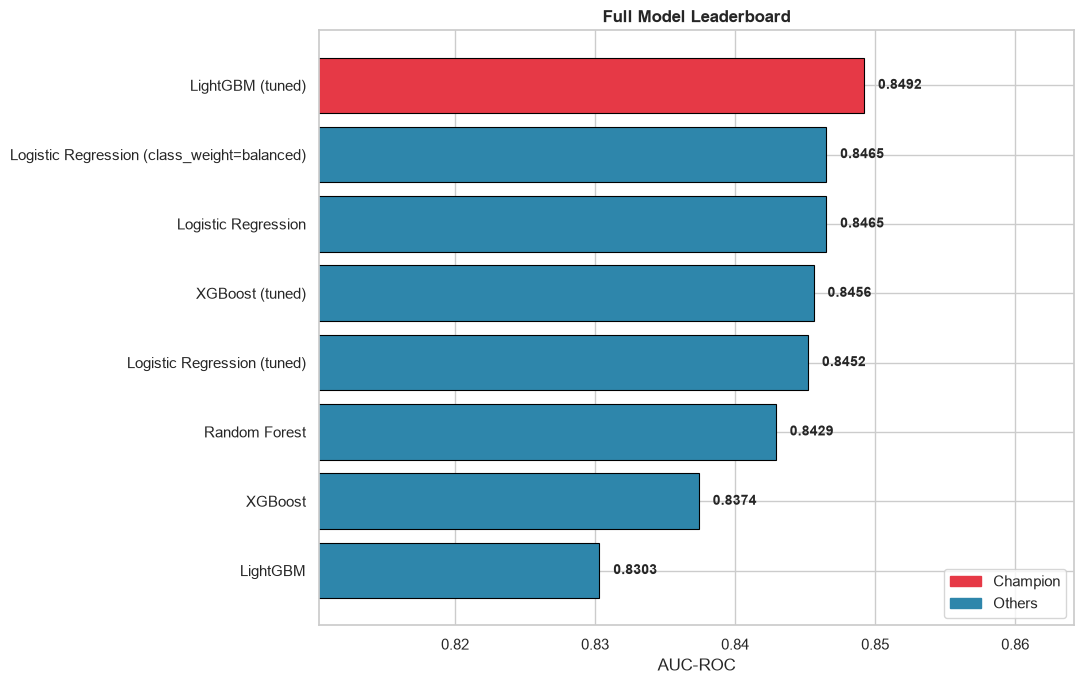

Saved -> NTB10_leaderboard.png


In [5]:
results_df = pd.read_csv(REPORTS_DIR / "model_results.csv").sort_values('auc_roc', ascending=True)
fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#E63946' if m == prod_config['model_name'] else '#2E86AB' for m in results_df['model']]
bars = ax.barh(results_df['model'], results_df['auc_roc'], color=colors, edgecolor='black', lw=0.8)
for bar, val in zip(bars, results_df['auc_roc']):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f"{val:.4f}", va='center', fontweight='bold', fontsize=10)
ax.set_xlim(results_df['auc_roc'].min()-0.02, results_df['auc_roc'].max()+0.015)
ax.set_xlabel('AUC-ROC'); ax.set_title('Full Model Leaderboard', fontweight='bold')
ax.legend(handles=[mpatches.Patch(color='#E63946',label='Champion'),
                   mpatches.Patch(color='#2E86AB',label='Others')], loc='lower right')
plt.tight_layout(); plt.savefig(FIG_DIR / "NTB10_leaderboard.png"); plt.show()
print("Saved -> NTB10_leaderboard.png")

## 4. Assemble `artifacts/` Directory

**This cell must run before the smoke test in Cell 6.**

In [6]:
# Copy the 4 files the API needs — nothing else
shutil.copy(MODELS_DIR  / "champion.joblib",              ARTIFACTS_DIR / "champion.joblib")
shutil.copy(MODELS_DIR  / "preprocessor.joblib",          ARTIFACTS_DIR / "preprocessor.joblib")
shutil.copy(REPORTS_DIR / "ntb08_production_config.json", ARTIFACTS_DIR / "production_config.json")
shutil.copy(PROC_DIR    / "feature_metadata.json",        ARTIFACTS_DIR / "feature_metadata.json")

print("artifacts/ contents:")
for f in sorted(ARTIFACTS_DIR.iterdir()):
    print(f"  {f.name:35s}  {f.stat().st_size/1024:>8.1f} KB")
print("\nartifacts/ is ready for NTB-11 (FastAPI) and NTB-13 (Docker).")

artifacts/ contents:
  champion.joblib                        1066.4 KB
  feature_metadata.json                     2.1 KB
  preprocessor.joblib                       8.0 KB
  production_config.json                    1.0 KB

artifacts/ is ready for NTB-11 (FastAPI) and NTB-13 (Docker).


## 5. Write `src/predict.py`

In [7]:
predict_py_content = 'import pandas as pd\nimport numpy as np\nimport joblib\nimport json\nfrom pathlib import Path\n\n_ARTIFACTS_DIR = Path(__file__).parent.parent / "artifacts"\n\n_model = None\n_preprocessor = None\n_config = None\n_feature_meta = None\n\n\ndef _load_artifacts():\n    global _model, _preprocessor, _config, _feature_meta\n    if _model is None:\n        _model        = joblib.load(_ARTIFACTS_DIR / "champion.joblib")\n        _preprocessor = joblib.load(_ARTIFACTS_DIR / "preprocessor.joblib")\n        with open(_ARTIFACTS_DIR / "production_config.json") as f:\n            _config = json.load(f)\n        with open(_ARTIFACTS_DIR / "feature_metadata.json") as f:\n            _feature_meta = json.load(f)\n\n\ndef predict_single(customer: dict, threshold: float = None) -> dict:\n    """\n    Predict churn probability for a single customer.\n\n    Parameters\n    ----------\n    customer : dict\n        Raw customer attributes. Required keys match the training schema.\n    threshold : float, optional\n        Classification threshold. Defaults to production_config optimal.\n\n    Returns\n    -------\n    dict with keys:\n        churn_probability : float\n        churn_prediction  : int (0 or 1)\n        threshold_used    : float\n        risk_tier         : str  (\'high\' / \'medium\' / \'low\')\n        top_risk_factors  : list[str]\n    """\n    _load_artifacts()\n\n    if threshold is None:\n        threshold = _config.get("optimal_threshold_business_value", 0.5)\n\n    all_features = (\n        _feature_meta["numeric_features"] +\n        _feature_meta["binary_features"] +\n        _feature_meta["categorical_features"]\n    )\n    row = pd.DataFrame([{k: customer.get(k, np.nan) for k in all_features}])\n\n    # Engineered features (mirrors NTB-02)\n    months = row["tenure_months"].iloc[0]\n    if months <= 6:    row["tenure_phase"] = "phase1_0to6"\n    elif months <= 12: row["tenure_phase"] = "phase2_7to12"\n    elif months <= 24: row["tenure_phase"] = "phase3_13to24"\n    elif months <= 48: row["tenure_phase"] = "phase4_25to48"\n    else:              row["tenure_phase"] = "phase5_49plus"\n\n    row["is_new_customer"]    = int(months <= 6)\n    row["has_internet"]       = int(row["internet_service"].iloc[0] != "No")\n    addon_cols = ["online_security", "online_backup", "device_protection",\n                  "tech_support", "streaming_tv", "streaming_movies"]\n    row["num_addons"]         = sum(1 for c in addon_cols if customer.get(c) == "Yes")\n    row["risky_payment"]      = int(row["payment_method"].iloc[0] == "Electronic check")\n    row["auto_payment"]       = int(row["payment_method"].iloc[0] in\n                                    ["Bank transfer (automatic)", "Credit card (automatic)"])\n    row["charges_per_tenure"] = row["monthly_charges"].iloc[0] / (months + 1)\n    row["high_value_customer"] = int(row["monthly_charges"].iloc[0] > 79.65)\n\n    row_aligned = row.reindex(columns=all_features)\n    X_processed = _preprocessor.transform(row_aligned)\n\n    proba = float(_model.predict_proba(X_processed)[:, 1][0])\n    prediction = int(proba >= threshold)\n\n    if proba >= 0.7:   risk_tier = "high"\n    elif proba >= 0.35: risk_tier = "medium"\n    else:               risk_tier = "low"\n\n    return {\n        "churn_probability": round(proba, 4),\n        "churn_prediction":  prediction,\n        "threshold_used":    threshold,\n        "risk_tier":         risk_tier,\n        "top_risk_factors":  _config.get("top_features_shap", [])[:5],\n    }\n\n\ndef predict_batch(customers: list, threshold: float = None) -> list:\n    """Predict churn for a list of customer dicts."""\n    return [predict_single(c, threshold) for c in customers]\n\n\ndef get_model_info() -> dict:\n    """Return production config metadata."""\n    _load_artifacts()\n    return {\n        "model_name":        _config.get("model_name"),\n        "auc_roc":           _config.get("test_auc_roc"),\n        "pr_auc":            _config.get("test_pr_auc"),\n        "optimal_threshold": _config.get("optimal_threshold_business_value"),\n        "monthly_value_usd": _config.get("optimal_monthly_value_usd"),\n        "top_features":      _config.get("top_features_shap", [])[:5],\n        "created_at":        _config.get("created_at"),\n    }\n'

predict_path = SRC_DIR / "predict.py"
with open(predict_path, "w") as f:
    f.write(predict_py_content)
print(f"Written -> {predict_path}  ({predict_path.stat().st_size/1024:.1f} KB)")
print(f"Lines:    {len(predict_py_content.splitlines())}")

Written -> c:\Users\Prakhar kapoor\Desktop\Telecom-Churn-Prediction-Analytics\src\predict.py  (4.2 KB)
Lines:    112


## 6. Smoke Test — Verify `predict.py` Works

This cell loads artifacts from disk. It will fail if Cell 4 (artifacts copy) has not been run yet.

In [8]:
import sys
sys.path.insert(0, str(SRC_DIR))
import importlib, predict; importlib.reload(predict)

high_risk = {
    "gender": "Male", "senior_citizen": 0, "partner": "No", "dependents": "No",
    "tenure_months": 2, "phone_service": "Yes", "multiple_lines": "No",
    "internet_service": "Fiber optic", "online_security": "No", "online_backup": "No",
    "device_protection": "No", "tech_support": "No", "streaming_tv": "Yes",
    "streaming_movies": "No", "contract_type": "Month-to-month",
    "paperless_billing": "Yes", "payment_method": "Electronic check",
    "monthly_charges": 79.85, "total_charges": 79.85,
}
safe = {
    "gender": "Female", "senior_citizen": 0, "partner": "Yes", "dependents": "Yes",
    "tenure_months": 60, "phone_service": "Yes", "multiple_lines": "Yes",
    "internet_service": "DSL", "online_security": "Yes", "online_backup": "Yes",
    "device_protection": "Yes", "tech_support": "Yes", "streaming_tv": "No",
    "streaming_movies": "No", "contract_type": "Two year",
    "paperless_billing": "No", "payment_method": "Bank transfer (automatic)",
    "monthly_charges": 55.00, "total_charges": 3300.00,
}

r_high = predict.predict_single(high_risk)
r_safe = predict.predict_single(safe)

print("High-risk customer:")
for k, v in r_high.items(): print(f"  {k}: {v}")
print("\nSafe customer:")
for k, v in r_safe.items(): print(f"  {k}: {v}")

assert r_high['churn_probability'] > r_safe['churn_probability'], "High-risk should score higher!"
assert r_high['risk_tier'] in ('high', 'medium')
assert r_safe['risk_tier'] == 'low'
print("\n  All sanity checks passed.")
print("\nModel info:", predict.get_model_info())

High-risk customer:
  churn_probability: 0.9026
  churn_prediction: 1
  threshold_used: 0.426
  risk_tier: high
  top_risk_factors: ['contract_type_Two year', 'charges_per_tenure', 'internet_service_Fiber optic', 'contract_type_One year', 'tenure_months']

Safe customer:
  churn_probability: 0.0384
  churn_prediction: 0
  threshold_used: 0.426
  risk_tier: low
  top_risk_factors: ['contract_type_Two year', 'charges_per_tenure', 'internet_service_Fiber optic', 'contract_type_One year', 'tenure_months']

  All sanity checks passed.

Model info: {'model_name': 'LightGBM (tuned)', 'auc_roc': 0.8492, 'pr_auc': 0.6628, 'optimal_threshold': 0.426, 'monthly_value_usd': 329527.0, 'top_features': ['contract_type_Two year', 'charges_per_tenure', 'internet_service_Fiber optic', 'contract_type_One year', 'tenure_months'], 'created_at': '2026-09-12T23:19:04.630736'}


## 7. Final Evaluation JSON & README Table

In [9]:
final_eval = {
    "project": "Telecom Customer Churn Prediction",
    "version": "1.0.0",
    "created_at": datetime.datetime.now().isoformat(),
    "model": {"name": prod_config["model_name"], "type": "LightGBMClassifier",
              "n_features": int(X_test.shape[1]),
              "train_samples": int(len(y_train)), "test_samples": int(len(y_test))},
    "performance": {
        "auc_roc": round(auc_roc,4), "pr_auc": round(pr_auc,4),
        "brier": round(brier,4), "log_loss": round(ll,4),
        "at_optimal_threshold": {
            "threshold": OPTIMAL_THRESHOLD,
            "precision": round(precision_opt,4), "recall": round(recall_opt,4),
            "f1": round(f1_opt,4), "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        },
    },
    "business": {
        "monthly_value_usd": prod_config["optimal_monthly_value_usd"],
        "retention_rate": prod_config["retention_rate_assumed"],
        "offer_cost_usd": prod_config["offer_cost_usd"],
    },
    "top_features": prod_config["top_features_shap"],
    "nlp_experiment": {"lift": -0.0008, "note": "Pipeline ready for real transcripts."},
    "artifacts": {
        "model": "artifacts/champion.joblib",
        "preprocessor": "artifacts/preprocessor.joblib",
        "config": "artifacts/production_config.json",
        "predict_module": "src/predict.py",
        "api": "api/main.py",
    }
}
with open(REPORTS_DIR / "final_evaluation.json", "w") as f:
    json.dump(final_eval, f, indent=2)
print("Saved -> reports/final_evaluation.json")

# README-ready table
print("\n--- README model table ---")
results_df = pd.read_csv(REPORTS_DIR / "model_results.csv").sort_values('auc_roc', ascending=False)
print("| Model | AUC-ROC | PR-AUC | F1@0.5 | Brier | CV AUC |")
print("|---|---|---|---|---|---|")
for _, row in results_df.iterrows():
    marker = " (champion)" if row['model'] == prod_config['model_name'] else ""
    cv = f"{row['cv_auc_mean']:.4f}" if pd.notna(row.get('cv_auc_mean')) else "n/a"
    print(f"| {row['model']}{marker} | {row['auc_roc']:.4f} | {row['pr_auc']:.4f} | {row['f1@0.5']:.4f} | {row['brier']:.4f} | {cv} |")

print(f"\nHEADLINE: LightGBM AUC={auc_roc:.4f}, recall={recall_opt*100:.0f}%, precision={precision_opt*100:.0f}% @ threshold {OPTIMAL_THRESHOLD}, value=${prod_config['optimal_monthly_value_usd']/1000:.0f}K/month")

Saved -> reports/final_evaluation.json

--- README model table ---
| Model | AUC-ROC | PR-AUC | F1@0.5 | Brier | CV AUC |
|---|---|---|---|---|---|
| LightGBM (tuned) (champion) | 0.8492 | 0.6628 | 0.6263 | 0.1588 | 0.8492 |
| Logistic Regression | 0.8465 | 0.6637 | 0.5797 | 0.1351 | 0.8483 |
| Logistic Regression (class_weight=balanced) | 0.8465 | 0.6640 | 0.6189 | 0.1645 | 0.8481 |
| XGBoost (tuned) | 0.8456 | 0.6619 | 0.6266 | 0.1634 | 0.8503 |
| Logistic Regression (tuned) | 0.8452 | 0.6599 | 0.6210 | 0.1652 | 0.8484 |
| Random Forest | 0.8429 | 0.6563 | 0.5780 | 0.1363 | 0.8440 |
| XGBoost | 0.8374 | 0.6405 | 0.5824 | 0.1392 | 0.8419 |
| LightGBM | 0.8303 | 0.6295 | 0.5796 | 0.1432 | 0.8350 |

HEADLINE: LightGBM AUC=0.8492, recall=85%, precision=50% @ threshold 0.426, value=$330K/month


## Deliverables From NTB-10

| Artifact | Path |
|---|---|
| `artifacts/` (4 files) | API-ready bundle — only thing Docker needs |
| `src/predict.py` | Importable prediction module for FastAPI |
| Final 4-panel plot | `reports/figures/NTB10_final_evaluation.png` |
| Leaderboard plot | `reports/figures/NTB10_leaderboard.png` |
| Model card JSON | `reports/final_evaluation.json` |

## Project Status: 10/15 Notebooks Complete

**Next: NTB-11 is an actual FastAPI app (`api/main.py`), not a notebook.**
You run it with `uvicorn api.main:app --reload` and hit it from a browser or Postman.

Remaining: NTB-11 FastAPI app | NTB-12 Streamlit | NTB-13 Docker | NTB-14 SQL Dashboard